In [ ]:
"""


Data Structure: (Adjust data directories accordingly)


Observers:
|___________ Observer_1:
                ALI_surgical_w_catheter_m_7:
                |__________: *.txt
                ALI_surgical_w_catheter_m_6:
                |__________: *.txt

|___________ Observer_2:
                ALI_surgical_w_catheter_m_7:
                |__________: *.txt
                ALI_surgical_w_catheter_m_6:
                |__________: *.txt

Images:
|___________ ALI_surgical_w_catheter_m_7

                |__________: *.png
"""

# Validating the generated lebales by observers

*   Check the size of each text files, if empty flag them for bypass.
*   Check if text size have the proper feature stored in them, eg, Proteinaceous Debris.
*   Only return common, valid set of text labels for the next step.

In [ ]:
import os 

animal_model_list = os.listdir("images")
Obsevers = os.listdir("Observers")

for animal_model in animal_model_list:
    for observer in Obsevers:
        text_file_path = os.path.join("Observers", observer, animal_model)
        text_files = os.listdir(text_file_path)
        for text_file in text_files:
            full_text_path = os.path.join(text_file_path, text_file)
            if os.path.getsize(full_text_path) == 0:
                print(f"Empty file found: {full_text_path}")
                print("Deleting the empty file.")
                os.remove(full_text_path)
            else:
                with open(full_text_path, 'r') as f:
                    content = f.read()
                    if "Proteinaceous Debris" not in content:
                        print(f"Missing feature in file: {full_text_path}")
                        print("Deleting the invalid file.")
                        os.remove(full_text_path)

Empty file found: Observers/labels_Eva/ALI_surgical_w_catheter_m_7/Aswcm7tile_52384_163898_coords.txt
Deleting the empty file.
Empty file found: Observers/labels_Eva/ALI_surgical_w_catheter_m_7/Aswcm7tile_39288_13234_coords.txt
Deleting the empty file.
Empty file found: Observers/labels_Eva/ALI_surgical_w_catheter_m_7/Aswcm7tile_52384_57008_coords.txt
Deleting the empty file.
Empty file found: Observers/labels_Eva/ALI_surgical_w_catheter_m_7/Aswcm7tile_50747_59044_coords.txt
Deleting the empty file.
Empty file found: Observers/labels_Eva/ALI_surgical_w_catheter_m_7/Aswcm7tile_45836_61080_coords.txt
Deleting the empty file.
Empty file found: Observers/labels_Eva/ALI_surgical_w_catheter_m_7/Aswcm7tile_45836_151682_coords.txt
Deleting the empty file.
Empty file found: Observers/labels_Eva/ALI_surgical_w_catheter_m_7/Aswcm7tile_55658_45810_coords.txt
Deleting the empty file.
Empty file found: Observers/labels_Eva/ALI_surgical_w_catheter_m_7/Aswcm7tile_45836_53954_coords.txt
Deleting the em

In [14]:
# Now we check for common valid files across observers by deleteing the non-common ones from both observers until having same number of text files.
for animal_model in animal_model_list:
    observer_paths = [os.path.join("Observers", observer, animal_model) for observer in Obsevers]
    text_files_lists = [set(os.listdir(path)) for path in observer_paths]
    
    common_files = set.intersection(*text_files_lists)
    
    for i, path in enumerate(observer_paths):
        current_files = set(os.listdir(path))
        files_to_remove = current_files - common_files
        for file in files_to_remove:
            full_path = os.path.join(path, file)
            print(f"Removing non-common file: {full_path}")
            os.remove(full_path)

Removing non-common file: Observers/labels_Prarthna/ALI_surgical_w_catheter_m_7/Aswcm7tile_44199_15270_coords.txt
Removing non-common file: Observers/labels_Prarthna/ALI_surgical_w_catheter_m_7/Aswcm7tile_50747_146592_coords.txt
Removing non-common file: Observers/labels_Prarthna/ALI_surgical_w_catheter_m_7/Aswcm7tile_50747_52936_coords.txt
Removing non-common file: Observers/labels_Prarthna/ALI_surgical_w_catheter_m_7/Aswcm7tile_47473_148628_coords.txt
Removing non-common file: Observers/labels_Prarthna/ALI_surgical_w_catheter_m_7/Aswcm7tile_49110_163898_coords.txt
Removing non-common file: Observers/labels_Prarthna/ALI_surgical_w_catheter_m_7/Aswcm7tile_52384_156772_coords.txt
Removing non-common file: Observers/labels_Prarthna/ALI_surgical_w_catheter_m_7/Aswcm7tile_54021_47846_coords.txt
Removing non-common file: Observers/labels_Prarthna/ALI_surgical_w_catheter_m_7/Aswcm7tile_55658_45810_coords.txt
Removing non-common file: Observers/labels_Prarthna/ALI_surgical_w_catheter_m_7/Aswc

Generate Yolo Format

In [24]:
import os
import numpy as np
from PIL import Image
from concurrent.futures import ProcessPoolExecutor

# Adjusted paths to match your structure
PATH_TO_TILES = os.path.expanduser('Tiles/')
PATH_TO_COORDS = os.path.expanduser('Observers/')
GENERATED_DIR = os.path.expanduser('Generated_Masks/')
RESIZED_TILES_DIR = os.path.expanduser('Resized_Tiles/')
YOLO_LABELS_DIR = os.path.expanduser('YOLO_Labels/')

IMAGE_SIZE_W = 1024
IMAGE_SIZE_L = 1024

os.makedirs(GENERATED_DIR, exist_ok=True)
os.makedirs(RESIZED_TILES_DIR, exist_ok=True)
os.makedirs(YOLO_LABELS_DIR, exist_ok=True)


def convert_to_yolo_format(x0, y0, x1, y1, img_width, img_height):
    """Convert (x0, y0, x1, y1) to YOLO format (x_center, y_center, width, height)."""
    x_center = (x0 + x1) / 2 / img_width
    y_center = (y0 + y1) / 2 / img_height
    width = (x1 - x0) / img_width
    height = (y1 - y0) / img_height
    return (
        max(0, min(1, x_center)),
        max(0, min(1, y_center)),
        max(0, min(1, width)),
        max(0, min(1, height)),
    )


def process_file(coord_file_path, tile_image_path,
                 resized_subfolder_path, generated_subfolder_path, yolo_labels_subfolder_path):
    if os.path.getsize(coord_file_path) == 0:
        print(f"Skipping {coord_file_path} because it is empty.")
        return

    # Match PNG filenames by stripping "_coords" from .txt
    base_name = os.path.basename(coord_file_path).replace("_coords.txt", "")
    with Image.open(tile_image_path) as img:
        orig_w, orig_h = img.size
        mask = np.zeros((orig_h, orig_w), dtype=np.uint8)
        yolo_labels = []

        with open(coord_file_path, "r") as file:
            lines = file.readlines()
            line_count = 0
            for line in lines:
                coords = line.strip().split(",")
                if len(coords) >= 4:
                    try:
                        x0, y0, x1, y1 = map(int, coords[:4])
                    except ValueError:
                        print(f"Skipping invalid line in {coord_file_path}: {line.strip()}")
                        continue

                    x_center, y_center, width, height = convert_to_yolo_format(
                        x0, y0, x1, y1, orig_w, orig_h
                    )
                    yolo_labels.append(f"0 {x_center} {y_center} {width} {height}")
                    mask[y0:y1, x0:x1] = 255
                    line_count += 1

        if line_count == 0:
            print(f"No valid annotations in {coord_file_path}")
            return

        # Save YOLO labels
        yolo_label_path = os.path.join(yolo_labels_subfolder_path, f"{base_name}_{line_count}.txt")
        with open(yolo_label_path, "w") as yolo_file:
            yolo_file.write("\n".join(yolo_labels))

        # Save resized mask + tile
        mask_resized = Image.fromarray(mask).resize((IMAGE_SIZE_W, IMAGE_SIZE_L), Image.NEAREST)
        img_resized = img.resize((IMAGE_SIZE_W, IMAGE_SIZE_L))

        resized_tile_path = os.path.join(resized_subfolder_path, f"{base_name}_{line_count}.png")
        img_resized.save(resized_tile_path)
        output_file_path = os.path.join(generated_subfolder_path, f"{base_name}_mask_{line_count}.png")
        mask_resized.save(output_file_path)


def process_subfolder(observer, animal_model):
    coords_subfolder_path = os.path.join(PATH_TO_COORDS, observer, animal_model)
    tiles_subfolder_path = os.path.join(PATH_TO_TILES, animal_model)

    generated_subfolder_path = os.path.join(GENERATED_DIR, observer, animal_model)
    resized_subfolder_path = os.path.join(RESIZED_TILES_DIR, observer, animal_model)
    yolo_labels_subfolder_path = os.path.join(YOLO_LABELS_DIR, observer, animal_model)

    if not os.path.exists(coords_subfolder_path):
        print(f"Skipping {observer}/{animal_model} (no coordinates folder).")
        return
    if not os.path.exists(tiles_subfolder_path):
        print(f"Skipping {observer}/{animal_model} (no images folder).")
        return

    os.makedirs(generated_subfolder_path, exist_ok=True)
    os.makedirs(resized_subfolder_path, exist_ok=True)
    os.makedirs(yolo_labels_subfolder_path, exist_ok=True)

    with ProcessPoolExecutor() as executor:
        futures = []
        for coord_file in os.listdir(coords_subfolder_path):
            if coord_file.endswith("_coords.txt"):  # ensure only valid files
                coord_file_path = os.path.join(coords_subfolder_path, coord_file)
                base_name = os.path.basename(coord_file).replace("_coords.txt", "")
                tile_image_path = os.path.join(tiles_subfolder_path, base_name + ".png")
                if not os.path.exists(tile_image_path):
                    print(f"Skipping {tile_image_path} (tile image missing).")
                    continue
                futures.append(
                    executor.submit(
                        process_file,
                        coord_file_path,
                        tile_image_path,
                        resized_subfolder_path,
                        generated_subfolder_path,
                        yolo_labels_subfolder_path,
                    )
                )
        for future in futures:
            future.result()


# Iterate over all observers + animal models
for observer in os.listdir(PATH_TO_COORDS):
    observer_path = os.path.join(PATH_TO_COORDS, observer)
    if os.path.isdir(observer_path):
        for animal_model in os.listdir(observer_path):
            animal_model_path = os.path.join(observer_path, animal_model)
            if os.path.isdir(animal_model_path):
                process_subfolder(observer, animal_model)


# Now we get the union/intersection of labels cross-observer.

In [ ]:
observer1_dir = "YOLO_Labels/labels_Eva/ALI_surgical_w_catheter_m_7/"
observer2_dir = "YOLO_Labels/labels_Prarthna/ALI_surgical_w_catheter_m_7/"
intersection_dir = "Intersection_Labels/ALI_surgical_w_catheter_m_7"
union_dir = "Union_Labels/ALI_surgical_w_catheter_m_7"

# print(os.listdir(observer1_dir))
os.makedirs(intersection_dir, exist_ok=True)
os.makedirs(union_dir, exist_ok=True)

def calculate_iou(box1, box2):
    x1_1, y1_1, x2_1, y2_1 = box1
    x1_2, y1_2, x2_2, y2_2 = box2

    x1 = max(x1_1, x1_2)
    y1 = max(y1_1, y1_2)
    x2 = min(x2_1, x2_2)
    y2 = min(y2_1, y2_2)
    intersection_area = max(0, x2 - x1) * max(0, y2 - y1)

    box1_area = (x2_1 - x1_1) * (y2_1 - y1_1)
    box2_area = (x2_2 - x1_2) * (y2_2 - y1_2)
    union_area = box1_area + box2_area - intersection_area

    iou = intersection_area / union_area if union_area > 0 else 0
    return iou

def get_prefix(file_name):
    parts = file_name.split('_')
    if len(parts) >= 3:
        return '_'.join(parts[:3])  
    return file_name

def to_yolo_format(box, class_id=0):
    x1, y1, x2, y2 = box
    x_center = (x1 + x2) / 2
    y_center = (y1 + y2) / 2
    width = x2 - x1
    height = y2 - y1
    return [class_id, x_center, y_center, width, height]

observer1_files = os.listdir(observer1_dir)
observer2_files = os.listdir(observer2_dir)


observer1_by_prefix = {get_prefix(f): f for f in observer1_files}
observer2_by_prefix = {get_prefix(f): f for f in observer2_files}


common_prefixes = set(observer1_by_prefix.keys()).intersection(observer2_by_prefix.keys())
print(f"Found {len(common_prefixes)} common prefixes between observers.")


for prefix in common_prefixes:
    observer1_file = observer1_by_prefix[prefix]
    observer2_file = observer2_by_prefix[prefix]
    observer1_path = os.path.join(observer1_dir, observer1_file)
    observer2_path = os.path.join(observer2_dir, observer2_file)


    observer1_boxes = []
    with open(observer1_path, "r") as f:
        lines = f.readlines()
        for line in lines:
            class_id, x_center, y_center, width, height = map(float, line.strip().split())
            x1 = (x_center - width / 2)
            y1 = (y_center - height / 2)
            x2 = (x_center + width / 2)
            y2 = (y_center + height / 2)
            observer1_boxes.append([x1, y1, x2, y2])


    observer2_boxes = []
    with open(observer2_path, "r") as f:
        lines = f.readlines()
        for line in lines:
            class_id, x_center, y_center, width, height = map(float, line.strip().split())
            x1 = (x_center - width / 2)
            y1 = (y_center - height / 2)
            x2 = (x_center + width / 2)
            y2 = (y_center + height / 2)
            observer2_boxes.append([x1, y1, x2, y2])


    intersection_boxes = []
    matched_o2_boxes = [False] * len(observer2_boxes)

    for o1_box in observer1_boxes:
        best_iou = 0.1  
        best_match = None

        for i, o2_box in enumerate(observer2_boxes):
            if not matched_o2_boxes[i]:
                iou = calculate_iou(o1_box, o2_box)
                if iou > best_iou:
                    best_iou = iou
                    best_match = o2_box
                    matched_idx = i

        if best_match is not None:

            avg_box = [
                (o1_box[0] + best_match[0]) / 2,
                (o1_box[1] + best_match[1]) / 2,
                (o1_box[2] + best_match[2]) / 2,
                (o1_box[3] + best_match[3]) / 2
            ]
            intersection_boxes.append(avg_box)
            matched_o2_boxes[matched_idx] = True

    union_boxes = observer1_boxes.copy()
    for i, o2_box in enumerate(observer2_boxes):
        if not matched_o2_boxes[i]:  
            union_boxes.append(o2_box)

    intersection_path = os.path.join(intersection_dir, f"{prefix}.txt")
    with open(intersection_path, "w") as f:
        for box in intersection_boxes:
            yolo_box = to_yolo_format(box)
            f.write(f"{yolo_box[0]} {yolo_box[1]} {yolo_box[2]} {yolo_box[3]} {yolo_box[4]}\n")

    union_path = os.path.join(union_dir, f"{prefix}.txt")
    with open(union_path, "w") as f:
        for box in union_boxes:
            yolo_box = to_yolo_format(box)
            f.write(f"{yolo_box[0]} {yolo_box[1]} {yolo_box[2]} {yolo_box[3]} {yolo_box[4]}\n")

# Final Visual Validation 

Yolo Dataset/dataset/labels/train/Aswcm7tile_22918_155754.txt


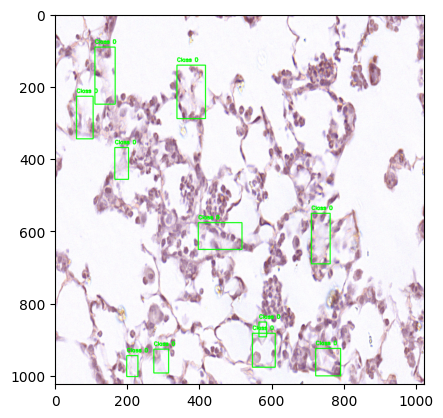

In [ ]:
import os
import cv2
import random
import re
import matplotlib.pyplot as plt 


images_dir = os.path.expanduser("Yolo_Dataset/dataset/images/train")
labels_dir = os.path.expanduser("Yolo_Dataset/dataset/labels/train")

image_files = [f for f in os.listdir(images_dir) if f.endswith(".png") or f.endswith(".jpg")]
if not image_files:
    print("No images found in the directory.")
    exit()

random_image_file = random.choice(image_files)
random_image_path = os.path.join(images_dir, random_image_file)
random_label_path = os.path.join(labels_dir, random_image_file.replace(".png", ".txt").replace(".jpg", ".txt"))
random_label_path = re.sub(r'(_\d+)?\.txt$', '.txt', random_label_path)

print(random_label_path)
image = cv2.imread(random_image_path)
if image is None:
    print(f"Failed to load image: {random_image_path}")
    exit()

image_height, image_width, _ = image.shape

with open(random_label_path, "r") as f:
    annotations = f.readlines()

for annotation in annotations:
    parts = annotation.strip().split()
    if len(parts) == 5:
        class_id, x_center, y_center, width, height = map(float, parts)
        
        x_center *= image_width
        y_center *= image_height
        width *= image_width
        height *= image_height
        
        x0 = int(x_center - width / 2)
        y0 = int(y_center - height / 2)
        x1 = int(x_center + width / 2)
        y1 = int(y_center + height / 2)
        
        cv2.rectangle(image, (x0, y0), (x1, y1), (0, 255, 0), 2) 
        cv2.putText(image, f"Class {int(class_id)}", (x0, y0 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))